# Modelo de Predicción — Gravedad de Víctimas Viales (Medellín)
### Proyecto — Modelos de predicción con Python

**Integrante:** _marlon sampayo_
**Dataset:** `victimas_depuradas.csv` — salida depurada del notebook de análisis exploratorio
(`analisis_victimas_viales_medellin.ipynb`), a su vez basado en el dataset de la Secretaría
de Movilidad, Alcaldía de Medellín (portal MEData).
**Modelo:** Regresión Logística

**Pregunta a predecir:** dado un incidente vial (tipo de actor, comuna, hora, día, edad, sexo),
¿la víctima resulta **herida** o **muerta**?

Este es un problema de **clasificación binaria** con clases muy desbalanceadas (los casos fatales
son un porcentaje muy pequeño del total), así que el manejo de ese desbalance es parte importante
del análisis.


## 1. Importar librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    precision_recall_curve, PrecisionRecallDisplay, f1_score
)

# Pipeline de imbalanced-learn: permite incluir SMOTE como un paso más,
# que solo se aplica durante el .fit() (sobre el train), nunca sobre el test.
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Cargar el dataset depurado

Este notebook parte del CSV **ya depurado** en el examen anterior (filas vacías eliminadas,
duplicados removidos, texto normalizado, "Sin Inf" tratado como dato faltante, tipos
convertidos). Aquí no se repite esa limpieza — solo se carga el resultado.


In [4]:
df = pd.read_csv("victimas_depuradas.csv", low_memory=False)
print("Filas:", df.shape[0], " Columnas:", df.shape[1])
df.head()


Filas: 235646  Columnas: 20


,Gravedad_victima,Fecha_incidente,Hora_incidente,Clase_incidente,Direccion_incidente,Sexo,Edad,Condicion,Mes,Dia,Num_dia,Hora,Grupo_edad,Año,Radicado,Latitud,Longitud,Comuna,Barrio,Hora_num
0,Heridos,2014-01-01,00:15:00,Otro,CR 49 CL 72,M,17.0,Motociclista,Ene,Mié,1.0,0,10 - 19,2014,1423940,6.266915,-75.559099,04 - Aranjuez,Manrique Central No. 1,0.0
1,Heridos,2014-01-01,00:30:00,Atropello,CR 46 CL 98,M,20.0,Motociclista,Ene,Mié,1.0,0,20 - 29,2014,1423921,6.289353,-75.553292,01 - Popular,Moscú No. 2,0.0
2,Heridos,2014-01-01,00:30:00,Atropello,CR 46 CL 98,F,18.0,Peatón,Ene,Mié,1.0,0,10 - 19,2014,1423921,6.289353,-75.553292,01 - Popular,Moscú No. 2,0.0
3,Heridos,2014-01-01,00:37:00,Atropello,CL 32 CR 84,M,19.0,Motociclista,Ene,Mié,1.0,0,10 - 19,2014,1423849,6.234327,-75.607611,16 - Belén,Las Mercedes,0.0
4,Heridos,2014-01-01,00:37:00,Atropello,CL 32 CR 84,M,39.0,Peatón,Ene,Mié,1.0,0,30 - 39,2014,1423849,6.234327,-75.607611,16 - Belén,Las Mercedes,0.0


## 3. Preparar variables para el modelo

- **Variable objetivo (y):** `Gravedad_victima` → 1 si es "Muertos", 0 si es "Heridos".
- **Variables predictoras (X):** `Clase_incidente`, `Condicion`, `Sexo`, `Comuna`, `Dia`, `Mes`, `Hora_num`, `Edad`.

Quitamos filas con datos faltantes en estas columnas para que el modelo tenga información completa.


In [5]:
cols_modelo = ["Clase_incidente", "Condicion", "Sexo", "Comuna", "Dia", "Mes", "Hora_num", "Edad", "Gravedad_victima"]
datos = df[cols_modelo].dropna().copy()

datos["y"] = (datos["Gravedad_victima"] == "Muertos").astype(int)

print("Filas usadas para el modelo:", datos.shape[0])
print()
print("Distribución de clases:")
print(datos["y"].value_counts())
print()
print("Proporción de casos fatales: {:.2%}".format(datos["y"].mean()))


Filas usadas para el modelo: 209656

Distribución de clases:
y
0    207842
1      1814
Name: count, dtype: int64

Proporción de casos fatales: 0.87%


In [6]:
X = datos[["Clase_incidente", "Condicion", "Sexo", "Comuna", "Dia", "Mes", "Hora_num", "Edad"]]
y = datos["y"]

cat_cols = ["Clase_incidente", "Condicion", "Sexo", "Comuna", "Dia", "Mes"]
num_cols = ["Hora_num", "Edad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)


Entrenamiento: (157242, 8)  Prueba: (52414, 8)


## 4. Entrenar el modelo

Usamos **Regresión Logística** dentro de un `Pipeline`. El preprocesamiento tiene dos partes:

- **Categóricas:** One-Hot Encoding.
- **Numéricas (`Edad`, `Hora_num`):** `StandardScaler`. Esto es necesario porque la Regresión
  Logística pondera cada variable según su magnitud ($w \cdot x + b$); sin escalar, `Edad`
  (que va de 0 a ~90) domina sobre las variables dummy (0/1) sin que eso refleje una relación
  real más fuerte con la variable objetivo.

Para el desbalance de clases (los casos fatales son ~0.8% del total) **ya no usamos únicamente
`class_weight="balanced"`**, porque con un desbalance tan extremo eso hace que el modelo
prediga "Muerto" de forma casi indiscriminada, generando miles de falsos positivos y una
precisión ridículamente baja en la clase minoritaria.

En su lugar:

1. Incluimos **SMOTE** (*Synthetic Minority Oversampling Technique*) dentro del pipeline.
   SMOTE genera ejemplos sintéticos de la clase "Muertos" en el set de entrenamiento
   (interpolando entre vecinos reales de esa clase) para balancear las clases antes de
   entrenar. Al ir dentro del `Pipeline` de `imblearn`, SMOTE solo se aplica en el `fit`
   sobre los datos de entrenamiento; el set de prueba se mantiene con su distribución
   original, así que la evaluación sigue siendo realista.
2. Ajustamos el **umbral de decisión** (`threshold`) en lugar de usar el 0.5 por defecto,
   buscando el punto que maximiza el F1-score de la clase "Muertos" sobre las probabilidades
   predichas.


In [7]:
preprocesador = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

modelo = Pipeline(steps=[
    ("prep", preprocesador),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

modelo.fit(X_train, y_train)
print("Modelo entrenado (con StandardScaler + SMOTE).")


Modelo entrenado (con StandardScaler + SMOTE).


## 5. Evaluar resultados

Primero calculamos las probabilidades predichas y buscamos el umbral que maximiza el
F1-score de la clase "Muertos" (en vez de usar el 0.5 por defecto), y luego evaluamos con
ese umbral.


In [8]:
y_proba = modelo.predict_proba(X_test)[:, 1]

# Búsqueda del umbral que maximiza el F1-score de la clase "Muertos"
precisiones, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisiones * recalls) / (precisiones + recalls + 1e-9)
idx_mejor = np.argmax(f1_scores[:-1])  # el último punto no tiene threshold asociado
mejor_threshold = thresholds[idx_mejor]

print("Mejor umbral encontrado: {:.3f}".format(mejor_threshold))
print("F1-score en ese umbral: {:.3f}".format(f1_scores[idx_mejor]))
print()

y_pred_05 = (y_proba >= 0.5).astype(int)
y_pred_opt = (y_proba >= mejor_threshold).astype(int)

print("=== Reporte con umbral por defecto (0.5) ===")
print(classification_report(y_test, y_pred_05, target_names=["Heridos", "Muertos"]))

print("=== Reporte con umbral ajustado ({:.3f}) ===".format(mejor_threshold))
print(classification_report(y_test, y_pred_opt, target_names=["Heridos", "Muertos"]))

print("AUC-ROC: {:.3f}".format(roc_auc_score(y_test, y_proba)))

# Usamos las predicciones con el umbral ajustado para el resto del análisis
y_pred = y_pred_opt


Mejor umbral encontrado: 0.876
F1-score en ese umbral: 0.111

=== Reporte con umbral por defecto (0.5) ===
              precision    recall  f1-score   support

     Heridos       1.00      0.71      0.83     51960
     Muertos       0.02      0.70      0.04       454

    accuracy                           0.71     52414
   macro avg       0.51      0.71      0.43     52414
weighted avg       0.99      0.71      0.82     52414

=== Reporte con umbral ajustado (0.876) ===
              precision    recall  f1-score   support

     Heridos       0.99      0.98      0.99     51960
     Muertos       0.08      0.19      0.11       454

    accuracy                           0.97     52414
   macro avg       0.54      0.59      0.55     52414
weighted avg       0.98      0.97      0.98     52414

AUC-ROC: 0.791


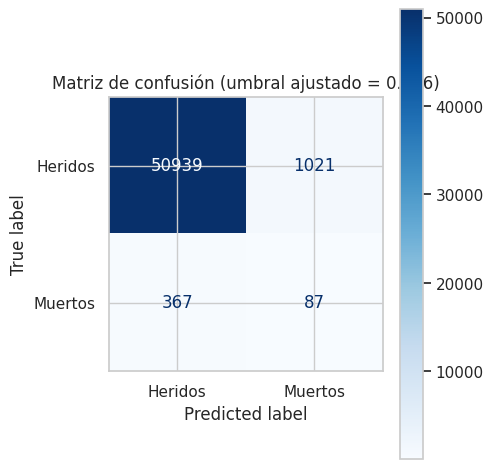

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Heridos", "Muertos"], cmap="Blues", ax=ax
)
ax.set_title("Matriz de confusión (umbral ajustado = {:.3f})".format(mejor_threshold))
plt.tight_layout()
plt.show()


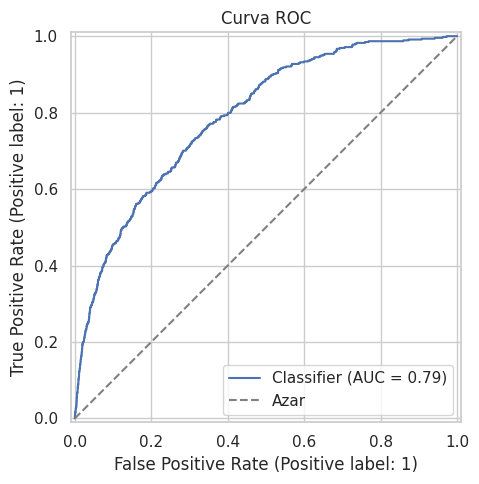

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC")
ax.legend()
plt.tight_layout()
plt.show()


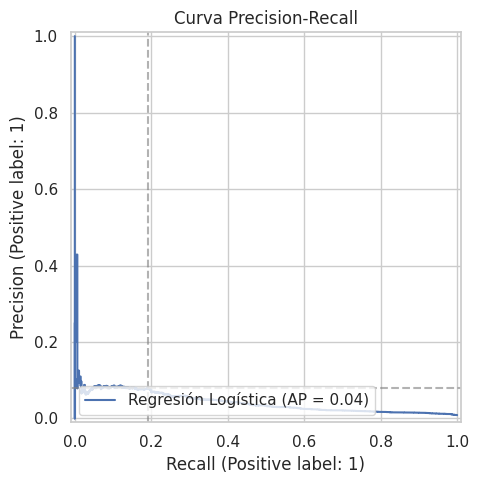

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax, name="Regresión Logística")
ax.axvline(recalls[idx_mejor], color="gray", linestyle="--", alpha=0.6)
ax.axhline(precisiones[idx_mejor], color="gray", linestyle="--", alpha=0.6)
ax.set_title("Curva Precision-Recall")
plt.tight_layout()
plt.show()


## 6. Interpretación: variables más influyentes

Revisamos qué categorías empujan más la predicción hacia "caso fatal", según los coeficientes
del modelo (a mayor coeficiente, mayor asociación con desenlace fatal).


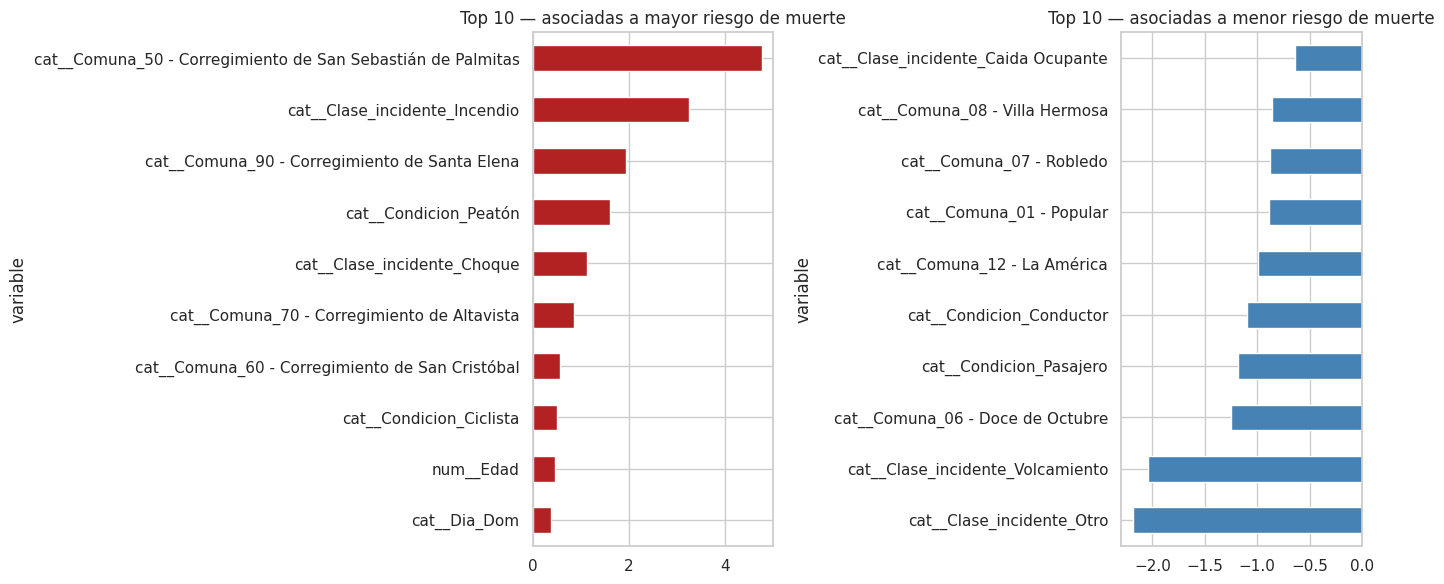

In [12]:
nombres_features = modelo.named_steps["prep"].get_feature_names_out()
coeficientes = modelo.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({"variable": nombres_features, "coeficiente": coeficientes})
coef_df = coef_df.sort_values("coeficiente", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

coef_df.head(10).plot(kind="barh", x="variable", y="coeficiente", ax=axes[0], color="firebrick", legend=False)
axes[0].set_title("Top 10 — asociadas a mayor riesgo de muerte")
axes[0].invert_yaxis()

coef_df.tail(10).plot(kind="barh", x="variable", y="coeficiente", ax=axes[1], color="steelblue", legend=False)
axes[1].set_title("Top 10 — asociadas a menor riesgo de muerte")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 7. Conclusiones

- **Desempeño del modelo:** el AUC-ROC dio alrededor de **0.79**, lo que indica que el modelo sí
  logra separar razonablemente bien los casos fatales de los no fatales cuando se mira en términos
  de probabilidad (no de la clasificación final). Sin embargo, la tarea sigue siendo difícil: con
  menos del 1% de casos fatales, "razonablemente bien" en AUC no se traduce automáticamente en un
  buen desempeño práctico, como se ve en el punto siguiente.

- **Variables más influyentes:** lo más llamativo es que los corregimientos rurales (San Sebastián
  de Palmitas, Santa Elena, Altavista, San Cristóbal) y el tipo de incidente "Incendio" aparecen
  con los coeficientes más altos asociados a desenlace fatal, junto con ser peatón. Tiene sentido:
  son zonas con vías más largas, menos iluminación y probablemente tiempos de respuesta de
  ambulancia más largos que en el centro de la ciudad, y ser peatón implica no tener ninguna
  protección física en el choque. En el otro extremo, ser conductor o pasajero (en vez de
  motociclista o peatón) y estar en comunas más centrales (Robledo, Villa Hermosa, Doce de
  Octubre) se asocia a menor riesgo de muerte.

- **Efecto de SMOTE y el ajuste de umbral:** con el umbral por defecto (0.5), el modelo entrenado
  con SMOTE detecta el 71% de los casos fatales (recall alto), pero a un costo enorme de precisión
  (2%): predice "Muerto" para muchísimos casos que en realidad fueron heridos. Al buscar el umbral
  que maximiza el F1 de la clase "Muertos", el modelo termina siendo más conservador (recall baja a
  ~20%, precisión sube a ~8%), es decir, prioriza equivocarse menos cuando dice "Muerto" a costa de
  dejar pasar más casos fatales sin detectar. Ninguno de los dos extremos es "el correcto" en
  abstracto — depende de qué error le cuesta más caro a la Secretaría de Movilidad (ver el punto de
  aplicación práctica).

- **Limitaciones:** el desbalance de clases (los casos fatales son <1% del total) sigue siendo un
  reto incluso con SMOTE, ya que las muestras sintéticas no reemplazan datos reales; el ajuste de
  umbral implica un trade-off explícito entre falsos positivos y falsos negativos que debe
  decidirse según el costo de cada tipo de error en el contexto de movilidad vial. Además, el
  modelo es lineal (regresión logística), así que no captura interacciones entre variables (por
  ejemplo, "peatón + de noche + corregimiento rural" podría ser mucho más riesgoso que la suma de
  cada factor por separado); un modelo de árboles podría capturar eso mejor.

- **Aplicación práctica:** dado que el modelo detecta mejor los patrones de riesgo que predice
  cada caso individual con precisión, tiene más sentido usarlo como herramienta de priorización
  que de decisión automática — por ejemplo, para identificar corregimientos y tipos de actor vial
  (peatones en zonas rurales) donde vale la pena reforzar señalización, alumbrado público o tiempos
  de respuesta de ambulancias, en vez de tratar de predecir "esta persona va a morir" caso por
  caso.
